In [35]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [36]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint
from scipy.special import erf

from jax import config
config.update("jax_enable_x64", True)

import math

In [37]:
t0, tfinal = 0.0, 1.0

In [38]:
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0
grav = 9.81

In [76]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [39]:
@jax.jit
def calc_H(x1, x2, y1, y2) :

    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))- \
        (m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

    return H   

In [40]:
def defineCollocationPoints(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)
    
    x1s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    x2s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    y1s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    y2s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    Hs = calc_H(x1s, x2s, y1s, y2s)

    ode_points = np.column_stack((ode_points, Hs))
    zsensors = np.column_stack((x1s, x2s, y1s, y2s))

    return (ode_points, zsensors)

In [41]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [42]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [43]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [44]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [45]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if t.ndim == 1:
      t = jnp.reshape(t, (1,-1))

    x1_0 = u[:,:1]
    x2_0 = u[:,1:2]
    y1_0 = u[:,2:3]
    y2_0 = u[:,3:]

    t_0 = t[:, :1]
    H_0 = t[:, 1:]

    b = Normalize(self.t0, self.tfinal)(t_0)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:,:self.units]
    trunk_x2 = trunk_net[:,self.units:2*self.units]
    trunk_y1 = trunk_net[:,2*self.units:3*self.units]
    trunk_y2 = trunk_net[:,3*self.units:]

    branch_x1 = branch_net[:,:self.units]
    branch_x2 = branch_net[:,self.units:2*self.units]
    branch_y1 = branch_net[:,2*self.units:3*self.units]
    branch_y2 = branch_net[:,3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t_0, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t_0, y2])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [46]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [47]:
(de_points, zsensors) = defineCollocationPoints([t0, tfinal], 1000)
print(de_points.shape, zsensors.shape)

(1000, 2) (1000, 4)


In [48]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

19960


In [49]:
@partial(jax.jit, static_argnums=(2,))
def w_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def w(t, z, component, params):
  return jax.vmap(w_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def w_t(t, z, component, params):
  return jax.vmap(jax.grad(w_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

    H_0 = t[:, -1]

    x1 = w(t, z, 0, params)
    x2 = w(t, z, 1, params)
    y1 = w(t, z, 2, params)
    y2 = w(t, z, 3, params)
    
    x1_t = w_t(t, z, 0, params)
    x2_t = w_t(t, z, 1, params)
    y1_t = w_t(t, z, 2, params)
    y2_t = w_t(t, z, 3, params)

    x1_t, x2_t, y1_t, y2_t = x1_t[:, 0], x2_t[:, 0], y1_t[:, 0], y2_t[:, 0]

    H = calc_H(x1, x2, y1, y2)

    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))
    H_loss = H - H_0

    x1_t_loss = jnp.mean(jnp.square(x1_t_loss))
    x2_t_loss = jnp.mean(jnp.square(x2_t_loss))
    y1_t_loss = jnp.mean(jnp.square(y1_t_loss))
    y2_t_loss = jnp.mean(jnp.square(y2_t_loss))
    H_loss = jnp.mean(jnp.square(H_loss))

    diff_loss = x1_t_loss + x2_t_loss + y1_t_loss + y2_t_loss
    
    return diff_loss + H_loss

@jax.jit
def train_step(params, pdes, z):
  t = pdes[:,:]
  return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [50]:
def train_network(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(zsensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [51]:
epochs = 5000
params, loss = train_network(params, de_points, zsensors, epochs)

Loss in epoch 0: 3.700424256084359
Loss in epoch 100: 0.028033319148456793
Loss in epoch 200: 0.016768350422066106
Loss in epoch 300: 0.014536286601180932
Loss in epoch 400: 0.013269098367740189
Loss in epoch 500: 0.011456858922396033
Loss in epoch 600: 0.007712226656701999
Loss in epoch 700: 0.006329609497169311
Loss in epoch 800: 0.019708955567365193
Loss in epoch 900: 0.015533593100045656
Loss in epoch 1000: 0.00456136415717868
Loss in epoch 1100: 0.00409120464549243
Loss in epoch 1200: 0.0037733518274735978
Loss in epoch 1300: 0.0036649644734374196
Loss in epoch 1400: 0.002990563106226019
Loss in epoch 1500: 0.0037826187261995664
Loss in epoch 1600: 0.0028133821109160855
Loss in epoch 1700: 0.00434953651873543
Loss in epoch 1800: 0.0030146398469663837
Loss in epoch 1900: 0.002585850141582342
Loss in epoch 2000: 0.0035924830013689983
Loss in epoch 2100: 0.0035797780408159006
Loss in epoch 2200: 0.0026815771072383286
Loss in epoch 2300: 0.002230061861355321
Loss in epoch 2400: 0.0018

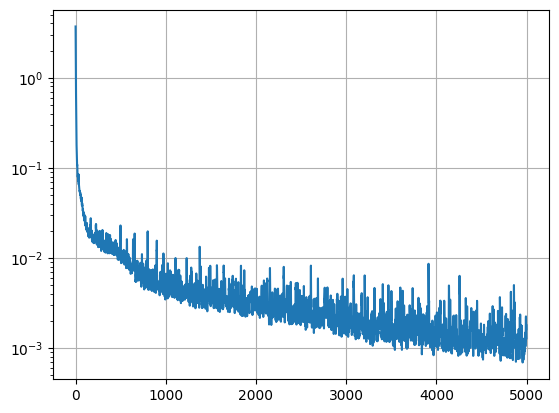

In [52]:
plt.semilogy(loss)
plt.grid()

In [53]:
def doublePendulum(w, t):
    
    x1, x2, y1, y2 = w
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    x1_t = (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t = (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t = -(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2))
    y2_t = -m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2))

    dwdt = [x1_t, x2_t, y1_t, y2_t]

    return dwdt

In [54]:
@jax.jit
def deriv_D(x, H_0) :

    x = jnp.reshape(x, (-1,))
    H_0 = jnp.reshape(H_0, (-1,))

    x1 = x[0]
    x2 = x[1]
    y1 = x[2]
    y2 = x[3]
    H_0 = H_0[0]

    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    H = calc_H(x1, x2, y1, y2)

    dH_dx1 = (m1 + m2)*grav*l1*jnp.sin(x1) + h1 - h2*jnp.sin(2*(x1 - x2))
    dH_dx2 = m2*grav*l2*jnp.sin(x2) - h1 + h2*jnp.sin(2*(x1 - x2))
    dH_dy1 = (l2*y1 - l1*y2*jnp.cos(x1-x2))/(l1*A)
    dH_dy2 = (l1*(m1+m2)*y2 - m2*l2*y1*jnp.cos(x1-x2))/(m2*l2*A)

    dD_dx1 = dH_dx1
    dD_dx2 = dH_dx2
    dD_dy1 = dH_dy1
    dD_dy2 = dH_dy2
    
    deriv_D = jnp.array([[dD_dx1, dD_dx2, dD_dy1, dD_dy2]])

    return deriv_D

In [55]:
@jax.jit
def func_D(x, H_0) :

    x = jnp.reshape(x, (-1,))
    H_0 = jnp.reshape(H_0, (-1,))
 
    x1 = x[0]
    x2 = x[1]
    y1 = x[2]
    y2 = x[3]
    H_0 = H_0[0]
   
    H = calc_H(x1, x2, y1, y2)

    D = H - H_0
    D = jnp.array([[D]])
    
    return D

In [56]:
@jax.jit
def newtons_root(x, H_0) :

    iter_num = 0

    H_0 = jnp.reshape(H_0, (-1, 1))

    while iter_num < 5 :

        x = jnp.reshape(x, (-1, 1))
        
        F = func_D(x, H_0)
        J = deriv_D(x, H_0)
        J_inv = jnp.linalg.pinv(J)

        x = x - J_inv@F

        iter_num = iter_num + 1

    return x

In [57]:
@jax.jit
def find_min_newton(x, H_0) :

    return jax.vmap(newtons_root, (0, 0), 0)(x, H_0)

In [58]:
class ClosestPoint(nn.Module):

    H_0: float
    
    @nn.compact
    def __call__(self, inputs):

        x_min = find_min_newton(inputs, self.H_0)
    
        return x_min

In [59]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if t.ndim == 1:
      t = jnp.reshape(t, (1,-1))

    x1_0 = u[:,:1]
    x2_0 = u[:,1:2]
    y1_0 = u[:,2:3]
    y2_0 = u[:,3:]

    t_0 = t[:, :1]
    H_0 = t[:, 1:]

    b = Normalize(self.t0, self.tfinal)(t_0)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:,:self.units]
    trunk_x2 = trunk_net[:,self.units:2*self.units]
    trunk_y1 = trunk_net[:,2*self.units:3*self.units]
    trunk_y2 = trunk_net[:,3*self.units:]

    branch_x1 = branch_net[:,:self.units]
    branch_x2 = branch_net[:,self.units:2*self.units]
    branch_y1 = branch_net[:,2*self.units:3*self.units]
    branch_y2 = branch_net[:,3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t_0, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t_0, y2])

    z = jnp.column_stack([x1, x2, y1, y2])
    z = ClosestPoint(H_0)(z)

    x1, x2, y1, y2 = z[:, :1], z[:, 1:2], z[:, 2:3], z[:, 3:]

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [60]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 4), 1.0, dtype = jnp.float64)

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [61]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

19960


In [62]:
Cparams = copy.deepcopy(params)

In [63]:
@partial(jax.jit, static_argnums=(2,))
def cw_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def cw(t, z, component, params):
  return jax.vmap(cw_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def cw_t(t, z, component, params):
  return jax.vmap(jax.grad(cw_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def closs(params, t, z):

    H_0 = t[:, -1]

    x1 = cw(t, z, 0, params)
    x2 = cw(t, z, 1, params)
    y1 = cw(t, z, 2, params)
    y2 = cw(t, z, 3, params)
    
    x1_t = cw_t(t, z, 0, params)
    x2_t = cw_t(t, z, 1, params)
    y1_t = cw_t(t, z, 2, params)
    y2_t = cw_t(t, z, 3, params)

    x1_t, x2_t, y1_t, y2_t = x1_t[:, 0], x2_t[:, 0], y1_t[:, 0], y2_t[:, 0]

    H = calc_H(x1, x2, y1, y2)

    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))
    H_loss = H - H_0

    x1_t_loss = jnp.mean(jnp.square(x1_t_loss))
    x2_t_loss = jnp.mean(jnp.square(x2_t_loss))
    y1_t_loss = jnp.mean(jnp.square(y1_t_loss))
    y2_t_loss = jnp.mean(jnp.square(y2_t_loss))
    H_loss = jnp.mean(jnp.square(H_loss))

    diff_loss = x1_t_loss + x2_t_loss + y1_t_loss + y2_t_loss
    
    return diff_loss + H_loss

@jax.jit
def ctrain_step(params, pdes, z):
  t = pdes[:,:]
  return jax.value_and_grad(closs)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [64]:
def ctrain_network(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  lr = 1e-4
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(zsensor)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = ctrain_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = coptimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 1 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [82]:
# epochs = 1000
# Cparams, loss = ctrain_network(Cparams, de_points, zsensors, epochs)

In [83]:
tree_info, shapes, Cparams_flat = flatten_pytree(Cparams)

In [84]:
@jax.jit
def loss_fun(params, t, z):

    return closs(params, t, z)


@jax.jit
def loss_grad_fun(params, t, z):
    
      return jax.grad(loss_fun, has_aux = False)(params, t, z)

In [85]:
@jax.jit
def computeH0(y, s):

  numerator = y.T@s
  denominator = y.T@y
  gamma = jnp.where(denominator > 0, numerator/denominator, 1.0)
  return gamma*jnp.eye(s.shape[0])


@jax.jit
def lineSearchBacktracking(x, p, g, t, z):       

    c1 = 1e-3
    gamma = 0.5
    max_iter = 15
  
    alpha_init = 1.0
    iter_init = 0
    
    args_init = alpha_init, iter_init

    def conditions(args) :

        alpha, iter = args
        
        xn = x + alpha*p

        params = reconstruct_pytree(tree_info, shapes, x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        fx = loss_fun(params, t, z)
        fxn = loss_fun(paramsn, t, z)

        cond1 = jax.lax.cond(fxn >= fx + c1*alpha*g.T@p , lambda x: True, lambda x: False, None)
        # cond2 = jax.lax.cond(iter < max_iter , lambda x: True, lambda x: False, None)
        # cond = jnp.logical_and(cond1, cond2)
        cond = cond1

        return cond

    def update_step(args) :

        alpha, iter = args
        
        iter = iter + 1
        alpha = alpha*gamma

        return (alpha, iter)

    
    alpha, _ = jax.lax.while_loop(conditions, update_step, args_init)   
    
    return alpha
    

@jax.jit
def body_fun_1(i, args) :

    rho, alpha, g, y, s, m = args

    i = m - i - 1
    
    rho.at[i].set(1.0 / (y[i].T @ s[i]))
    alpha.at[i].set(rho[i] * s[i].T @ g)
    g -= alpha[i] * y[i]

    return rho, alpha, g, y, s, m


@jax.jit
def body_fun_2(i, args) :

    rho, alpha, g, Hg, y, s = args
    
    beta = rho[i] * y[i].T @ Hg
    Hg += (alpha[i] - beta) * s[i]  

    return rho, alpha, g, Hg, y, s


In [86]:
def lbfgs(params, pdes, z, max_iters_val):

    max_iters = max_iters_val
    max_m = 5
    
    s = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    y = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    
    t = pdes
    
    losses = [loss_fun(params, t, z)]
    tree_info, shapes, x = flatten_pytree(params)
    
    g = loss_grad_fun(params,t , z)
    _, _, g = flatten_pytree(g)
    g = jnp.float64(g)

    
    for k in range(max_iters):

        m = k if k < max_m else max_m
        Hg = g if m == 0 else computeH0(y[m-1], s[m-1]) @ g

        if m > 0:

            alpha = jnp.zeros(m, dtype = jnp.float64)
            rho = jnp.zeros(m, dtype = jnp.float64)

            args_1 = (rho, alpha, g, y, s, m)
            rho, alpha, g, y, s, _ = jax.lax.fori_loop(0, m, body_fun_1, args_1)

            args_2 = (rho, alpha, g, Hg, y, s)
            rho, alpha, g, Hg, y, s = jax.lax.fori_loop(0, m, body_fun_2, args_2)

        Hg = -Hg

        eta = lineSearchBacktracking(x, Hg, g, t, z)
        xn = x + eta*Hg

        s.at[k, :].set(xn - x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        gn = loss_grad_fun(paramsn, t, z)
        _, _, gn = flatten_pytree(gn)

        y.at[k, :].set(gn - g)

        x = xn
        g = gn

        losses.append(loss_fun(paramsn, t, z))
     
        # if k % 10 == 0:
            
        #     print(f'Iteration: {k}, Loss: {losses[-1]}')

    return paramsn, losses

In [87]:
def ctrain_network_lbfgs(params, des, zsensor, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    ds_z = tf.data.Dataset.from_tensor_slices(zsensor)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)

    for i in range(epochs):
      
        print(i)
      
        for (des_batch, z_batch) in ds:
        
          params, loss = lbfgs(params, des_batch.numpy(), z_batch.numpy(), 5)
          epoch_loss[i] += loss[-1]

        epoch_loss[i] /= batch_size

        if i % 1 == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [88]:
epochs = 100
Cparams, loss_lbfgs = ctrain_network_lbfgs(Cparams, de_points, zsensors, epochs)

0
Loss in epoch 0: 0.0005625555698367216
1
Loss in epoch 1: 0.0004887298919066108
2
Loss in epoch 2: 0.0004695482004282667
3
Loss in epoch 3: 0.0004543134145121648
4
Loss in epoch 4: 0.000442592254075472
5
Loss in epoch 5: 0.00043143836551213317
6
Loss in epoch 6: 0.0004289324829859116
7
Loss in epoch 7: 0.0004220839813965758
8
Loss in epoch 8: 0.00041602027950489033
9
Loss in epoch 9: 0.00041699085284514575
10
Loss in epoch 10: 0.0004066951257171185
11
Loss in epoch 11: 0.0004188660440287966
12
Loss in epoch 12: 0.0004061180182809583
13
Loss in epoch 13: 0.00041375959232400997
14
Loss in epoch 14: 0.00039226410634954226
15
Loss in epoch 15: 0.00039169204654399215
16
Loss in epoch 16: 0.0003877002291267376
17
Loss in epoch 17: 0.00041261433249748186
18
Loss in epoch 18: 0.0004121349982321167
19
Loss in epoch 19: 0.00039486385403383445
20
Loss in epoch 20: 0.0003887550724564114
21
Loss in epoch 21: 0.000393345633920553
22
Loss in epoch 22: 0.0004044074654245275
23
Loss in epoch 23: 0.00

KeyboardInterrupt: 

In [125]:
n = 500
t = np.linspace(t0, tfinal, n)

x1_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
x2_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y1_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y2_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
H_data = calc_H(x1_data, x2_data, y1_data, y2_data)

init_data = np.column_stack([x1_data, x2_data, y1_data, y2_data])
init_data = np.reshape(init_data, (-1,))

H_init = np.repeat(np.expand_dims(H_data, axis=0), len(t), axis=0)
z_init = np.repeat(np.expand_dims(init_data, axis=0), len(t), axis=0)

t_data =  np.column_stack((t, H_init))

print(t_data.shape, z_init.shape)

sol_rk = odeint(doublePendulum, init_data, t, rtol=1e-12)
x1rk, x2rk, y1rk, y2rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2], sol_rk[:,3]
Hrk = calc_H(x1rk, x2rk, y1rk, y2rk)

(500, 2) (500, 4)


In [126]:
x1og = jax.vmap(w_model, [0, 0, None, None])(t_data, z_init, 0, params)
x2og = jax.vmap(w_model, [0, 0, None, None])(t_data, z_init, 1, params)
y1og = jax.vmap(w_model, [0, 0, None, None])(t_data, z_init, 2, params)
y2og = jax.vmap(w_model, [0, 0, None, None])(t_data, z_init, 3, params)
Hog = calc_H(x1og, x2og, y1og, y2og)

x1c = jax.vmap(cw_model, [0, 0, None, None])(t_data, z_init, 0, Cparams)
x2c = jax.vmap(cw_model, [0, 0, None, None])(t_data, z_init, 1, Cparams)
y1c = jax.vmap(cw_model, [0, 0, None, None])(t_data, z_init, 2, Cparams)
y2c = jax.vmap(cw_model, [0, 0, None, None])(t_data, z_init, 3, Cparams)
Hc = calc_H(x1c, x2c, y1c, y2c)

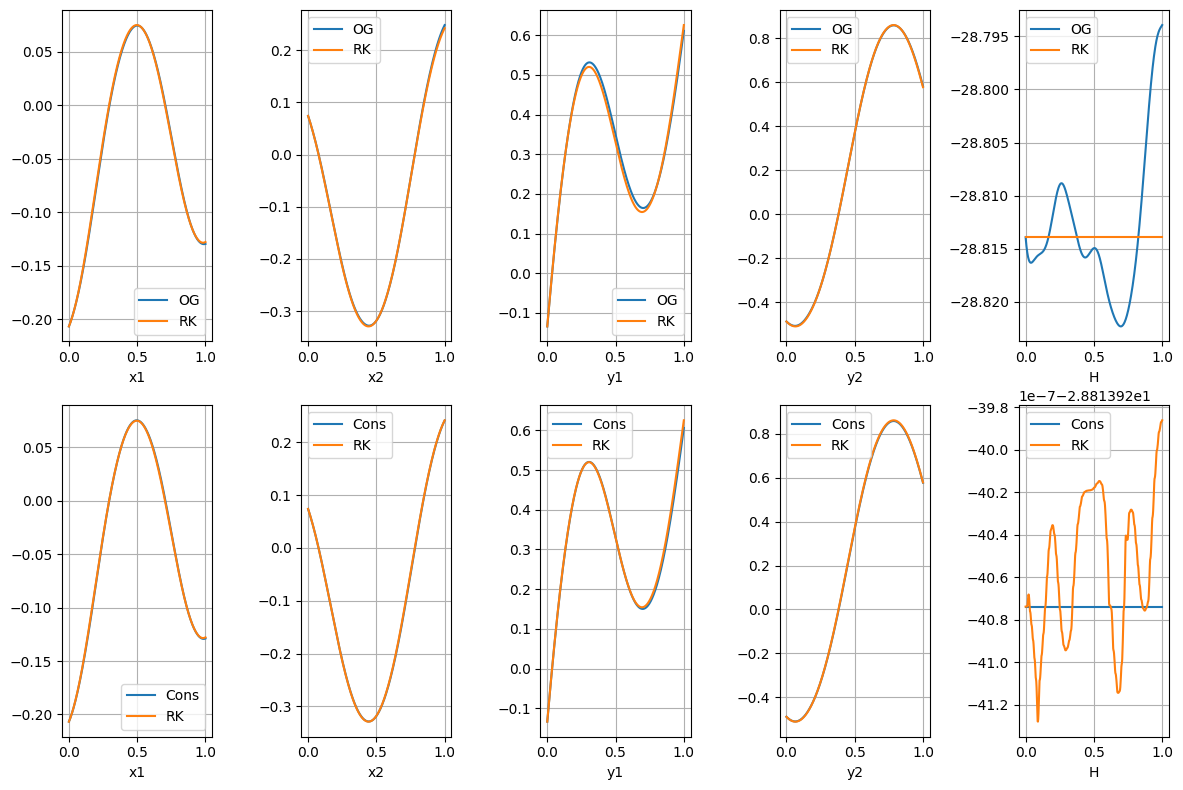

In [127]:
fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 5, 1)
plt.tight_layout()
plt.plot(t, x1og)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['OG','RK'])

plt.subplot(2, 5, 2)
plt.tight_layout()
plt.plot(t, x2og)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['OG','RK'])

plt.subplot(2, 5, 3)
plt.tight_layout()
plt.plot(t, y1og)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['OG','RK'])

plt.subplot(2, 5, 4)
plt.tight_layout()
plt.plot(t, y2og)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['OG','RK'])


plt.subplot(2, 5, 5)
plt.tight_layout()
plt.plot(t, Hog)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['OG','RK'])

plt.subplot(2, 5, 6)
plt.tight_layout()
plt.plot(t, x1c)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Cons','RK'])

plt.subplot(2, 5, 7)
plt.tight_layout()
plt.plot(t, x2c)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Cons','RK'])

plt.subplot(2, 5, 8)
plt.tight_layout()
plt.plot(t, y1c)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['Cons','RK'])

plt.subplot(2, 5, 9)
plt.tight_layout()
plt.plot(t, y2c)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['Cons','RK'])

plt.subplot(2, 5, 10)
plt.tight_layout()
plt.plot(t, Hc)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['Cons','RK'])

In [128]:
def run_test(num_models, num_exp, models_lst, params_lst, labels_lst, bfgs_lst) :

    n = 500
    t = np.linspace(t0, tfinal, n)
    
    
    preds = np.zeros( (num_exp, num_models, 5, n))
    preds_error = np.zeros((num_exp, num_models, 5))

    for i in range(num_exp) :

        print(i)

        x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        y1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        y2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        H_init = calc_H(x1_init, x2_init, y1_init, y2_init)
        
        data_model = np.column_stack([x1_init, x2_init, y1_init, y2_init])
        data_model = np.reshape(data_model, (-1,))
        data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
                
        H_model = np.reshape(H_init, (-1,))
        H_model = np.repeat(np.expand_dims(H_model, axis=0), n, axis=0)
        
        t_model = np.column_stack([t, H_model])
        
        data_rk = np.column_stack([x1_init, x2_init, y1_init, y2_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t
        
        sol_rk = odeint(doublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        x1rk, x2rk, y1rk, y2rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2], sol_rk[:,3]
        Hrk = calc_H(x1rk, x2rk, y1rk, y2rk)


        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]

            for k in range(4) :

                val = jax.vmap(model, [0, 0, None, None])(t_model, data_model, k, params)
                preds[i, j, k] = val

            preds[i, j, 4] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])

            if j in bfgs_lst :
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3]])
                
                H_0_arr = t_model[:, 1:]
        
                xbfgs = find_min_newton(args_arr, H_0_arr)
                xbfgs = np.reshape(xbfgs, (-1, 4))

                for l in range(4) :

                    preds[i, j, l] = xbfgs[:, l]
                    
                preds[i, j, 4] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])
                                       

            for m in range(4) :

                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, m]))

            preds_error[i, j, 4] = np.mean(np.abs(Hrk - preds[i, j, 4]))


    fig = plt.figure(figsize=(25, 20))

    num = [number for number in range(num_exp)]
    x_labels = ["x1", "x2", "y1", "y2", "H"] 

    for i in range(num_models) :
        
        for j in range(5) :
        
            plt.subplot(5, 1, j + 1)
            plt.tight_layout()
            plt.plot(num, preds_error[:, i, j], label = labels_lst[i])
            plt.xlabel(x_labels[j])
            plt.grid()
            plt.legend()

    plt.show()
    return preds, preds_error

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


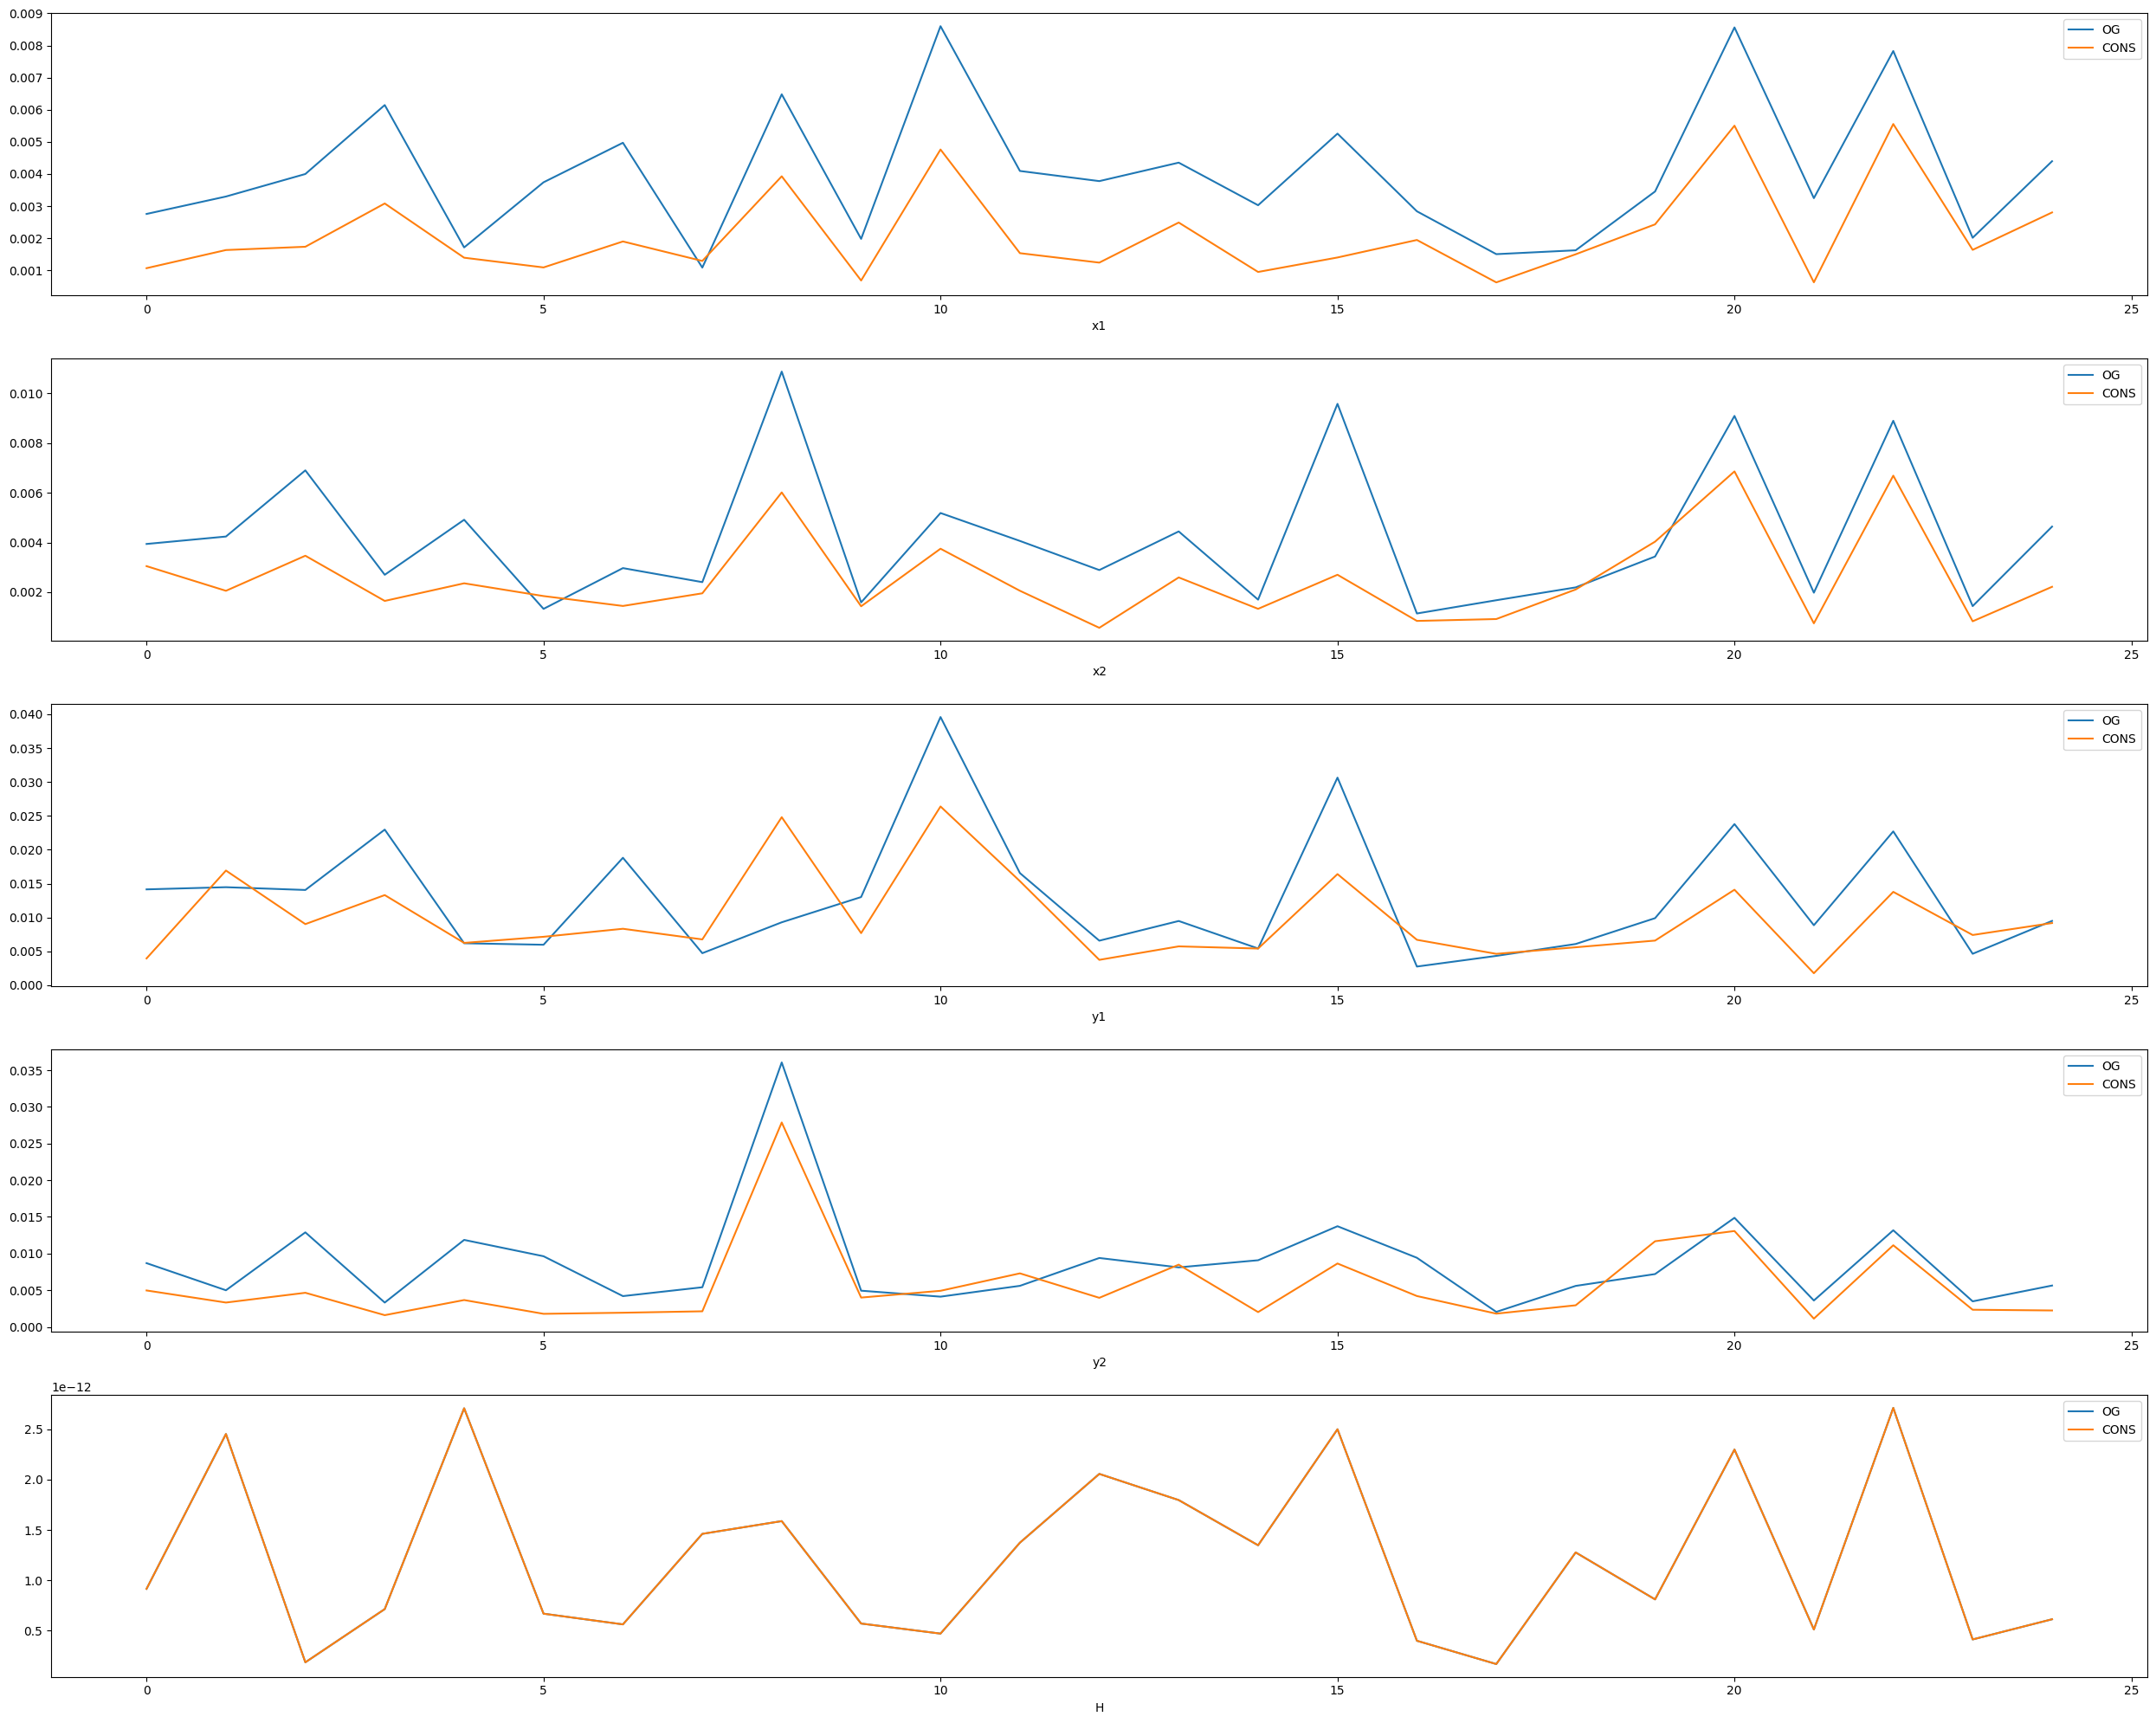

In [132]:
models_lst = [w_model, cw_model]
params_lst = [params, Cparams]
labels_lst = ["OG", "CONS"]
bfgs_lst = [0]

preds, preds_error = run_test(2, 25, models_lst, params_lst, labels_lst, bfgs_lst)

In [133]:
def time_step_run_test(t_end_val, num_models, num_exp, models_lst, params_lst, labels_lst, bfgs_lst) :

    
    n = 500
    t_start = 0.0
    t_end = t_end_val

    n_ts = int(n*(t_end/tfinal))
    t_step = t_end/n_ts
    
    num_cycles = math.ceil(n_ts/n)

    t_ts = np.linspace(t_start, t_end, n_ts)
      
    preds = np.zeros((num_exp, num_cycles, num_models, 5, n))
    preds_error = np.zeros((num_exp, num_cycles, num_models, 5))
    
    for i in range(num_exp) :

        print(i)

        x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        y1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        y2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
        H_init = calc_H(x1_init, x2_init, y1_init, y2_init)

        data_rk = np.column_stack([x1_init, x2_init, y1_init, y2_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t_ts
            
        sol_rk = odeint(doublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        x1rk, x2rk, y1rk, y2rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2], sol_rk[:,3]
        Hrk = calc_H(x1rk, x2rk, y1rk, y2rk)
        
        for c in range(num_cycles) :
            
            for j in range(num_models) :

                if c != 0 :
    
                    x1_init = preds[i, c-1, j, 0, -1].reshape((1,))
                    x2_init = preds[i, c-1, j, 1, -1].reshape((1,))
                    y1_init = preds[i, c-1, j, 2, -1].reshape((1,))
                    y2_init = preds[i, c-1, j, 3, -1].reshape((1,))
                    H_init = calc_H(x1_init, x2_init, y1_init, y2_init)

                data_model = np.column_stack([x1_init, x2_init, y1_init, y2_init])
                data_model = np.reshape(data_model, (-1,))
                data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
                
                H_model = np.reshape(H_init, (-1,))
                H_model = np.repeat(np.expand_dims(H_model, axis=0), n, axis=0)
                
                t_model = np.column_stack([t, H_model])

                
                model = models_lst[j]
                params = params_lst[j]
    
                for k in range(4) :
    
                    val = jax.vmap(model, [0, 0, None, None])(t_model, data_model, k, params)
                    preds[i, c, j, k] = val
    
                preds[i, c, j, 4] = calc_H(preds[i, c, j, 0], preds[i, c, j, 1], preds[i, c, j, 2], preds[i, c, j, 3])
    
                if j in bfgs_lst :
                    
                    args_arr = np.column_stack([preds[i, c, j, 0], preds[i, c, j, 1], preds[i, c, j, 2], preds[i, c, j, 3]])
                    
                    H_0_arr = t_model[:, 1:]
            
                    xbfgs = find_min_newton(args_arr, H_0_arr)
                    xbfgs = np.reshape(xbfgs, (-1, 4))

                    
                    for l in range(4) :
    
                        preds[i, c, j, l] = xbfgs[:, l]
                        
                    preds[i, c, j, 4] = calc_H(preds[i, c, j, 0], preds[i, c, j, 1], preds[i, c, j, 2],preds[i, c, j, 3])
                  
    
                for m in range(4) :
    
                    preds_error[i, c, j, m] = np.mean(np.abs(sol_rk[c*n:(c+1)*n, m] - preds[i, c, j, m]))
    
                preds_error[i, c, j, 4] = np.mean(np.abs(Hrk[c*n:(c+1)*n] - preds[i, c, j, 4]))
    

        fig = plt.figure(figsize=(25, 20))
    
        num = [number for number in range(num_exp)]
        x_labels = ["x1", "x2", "y1", "y2", "H"] 
    
    
        for i in range(num_models) :
    
            for j in range(5) :
                
                plt.subplot(5, 1, j + 1)
                plt.plot(t_ts, preds[0, :, i, j].flatten(), label = labels_lst[i])
                    
                plt.xlabel(x_labels[j])
                plt.grid()
                plt.legend()
    
        for j in range(5) :
        
            plt.subplot(5, 1, j + 1)
            
            if j != 4 :
                plt.plot(t_ts, sol_rk[:, j], label = "RK")
            else:
                plt.plot(t_ts, Hrk, label = "RK")
                
            plt.xlabel(x_labels[j])
            plt.grid()
            plt.legend()
        
        plt.show()
    
    return preds, preds_error

0


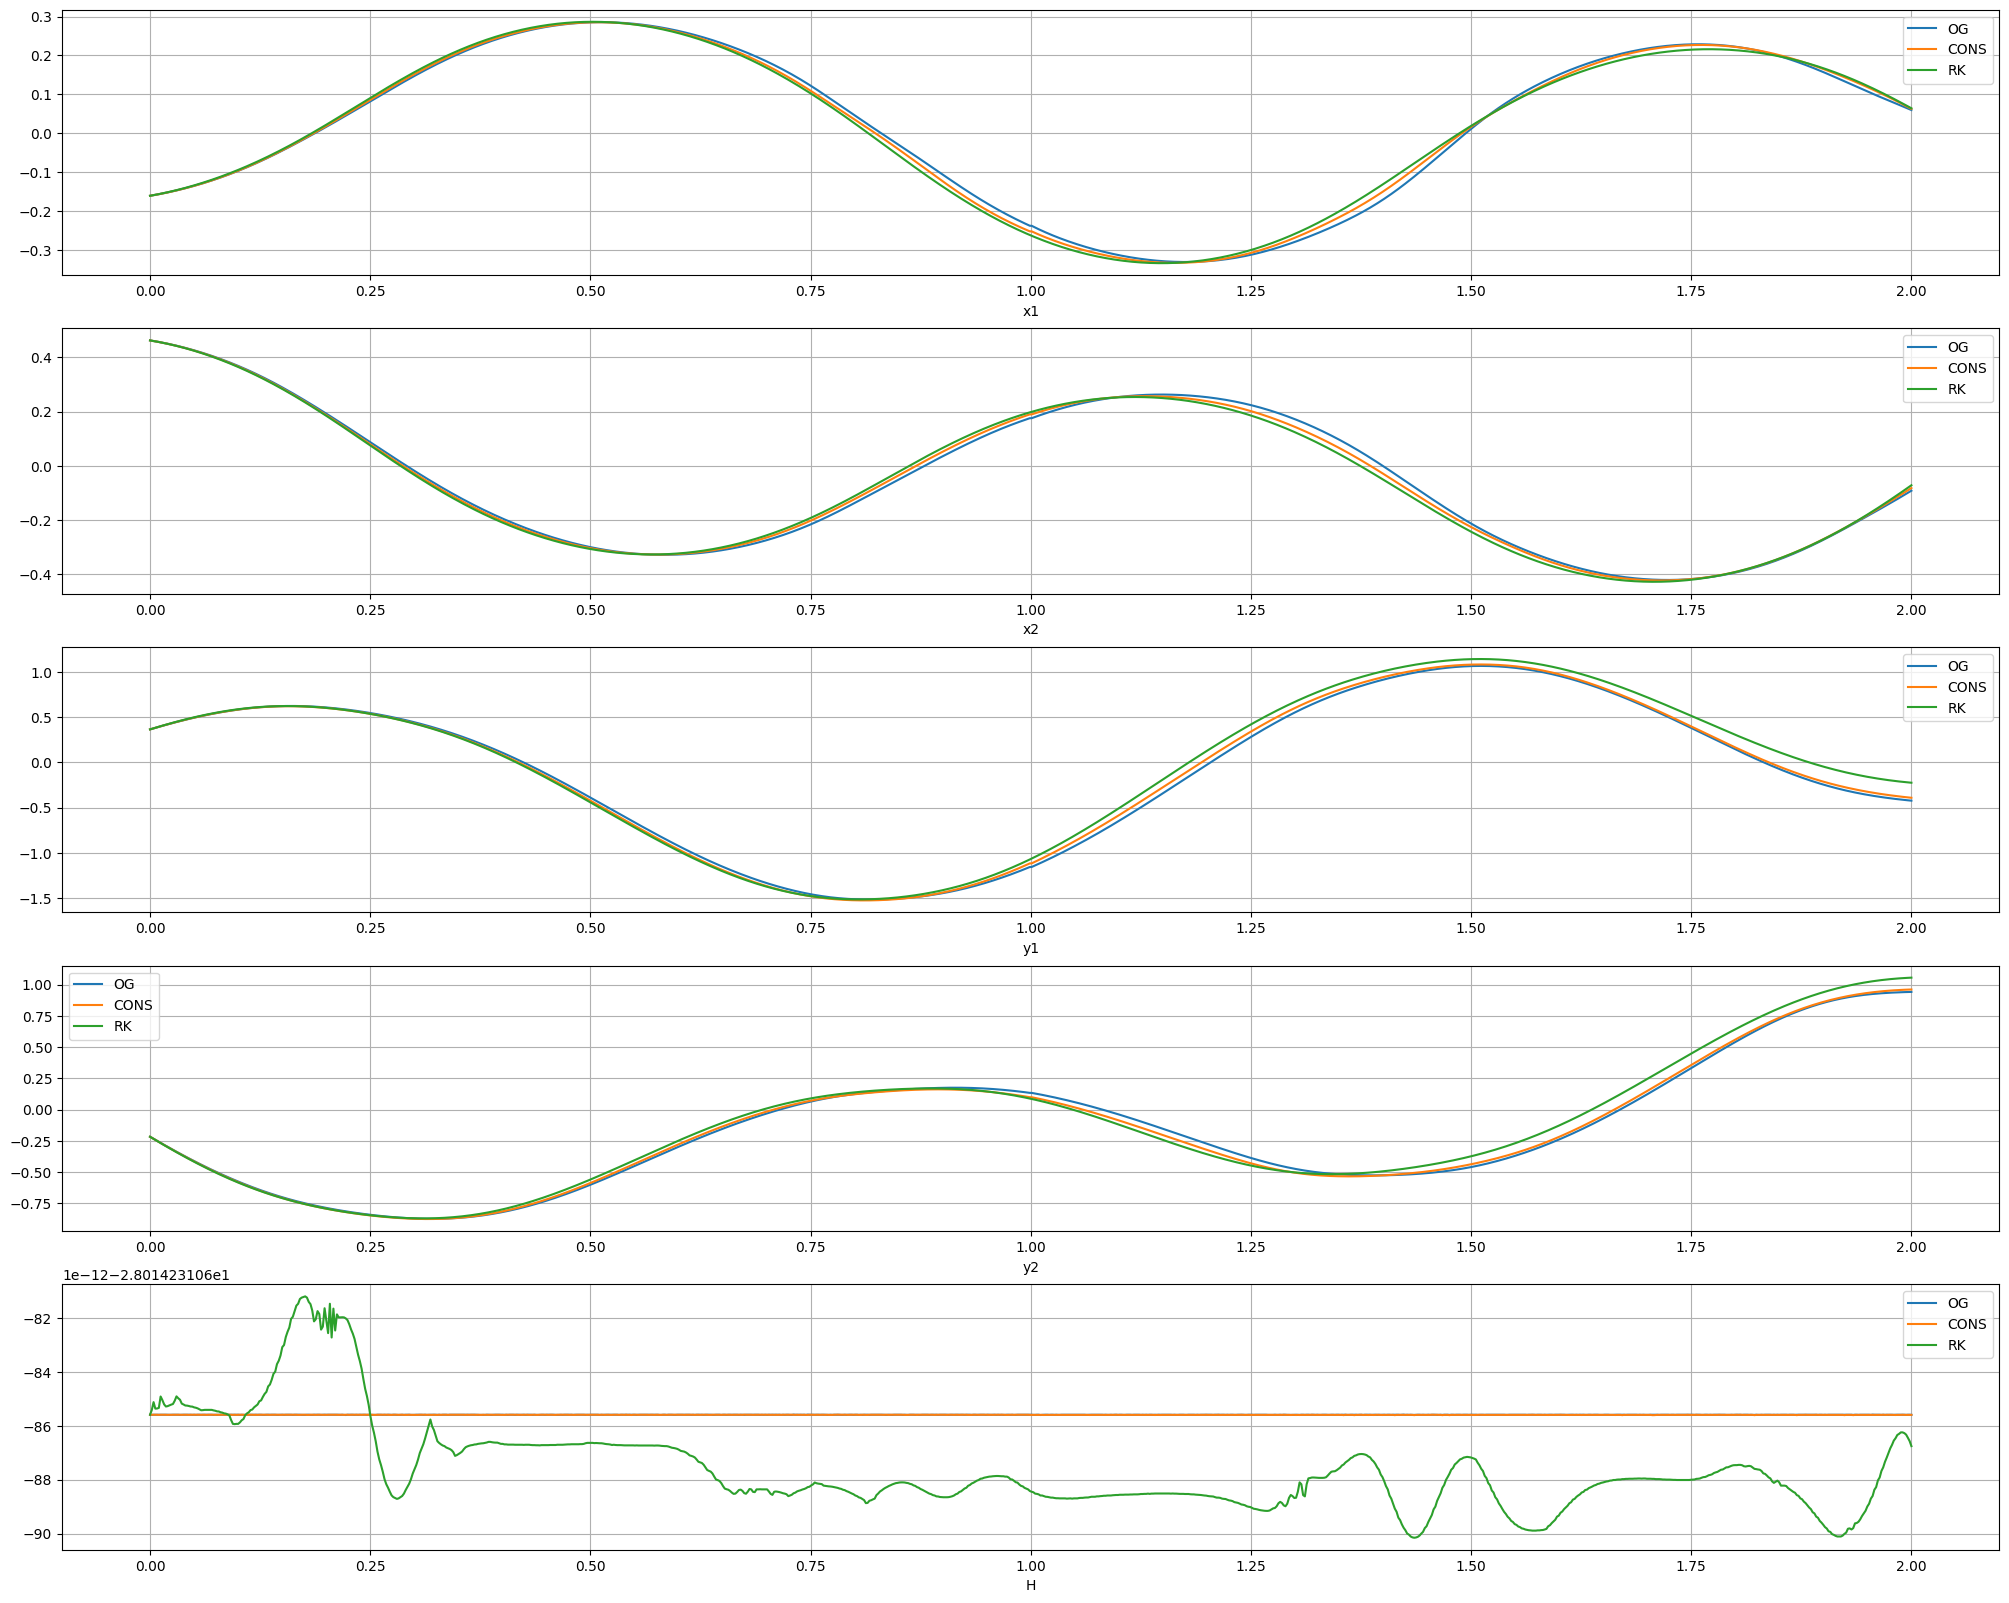

In [139]:
models_lst = [w_model, cw_model]
params_lst = [params, Cparams]
labels_lst = ["OG", "CONS"]
bfgs_lst = [0]

preds, preds_error = time_step_run_test(2.0, 2, 1, models_lst, params_lst, labels_lst, bfgs_lst)